In [9]:
#Import de bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [4]:
#Chargement du dataset breast_cancer
breast_cancer=load_breast_cancer()
X=breast_cancer.data
Y=breast_cancer.target
feature_names=breast_cancer.feature_names
class_names=breast_cancer.target_names
print("Taille de X:",X.shape)
print("Taille de Y:",Y.shape)

Taille de X: (569, 30)
Taille de Y: (569,)


In [6]:
#Séparation train et test
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.2,random_state=42)
#Entraînement du modèle
dt_model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)
dt_model.fit(X_train,Y_train)
#Prédiction
Y_pred=dt_model.predict(X_test)


In [7]:
#Evaluation
accuracy=accuracy_score(Y_test,Y_pred)
print("Accuracy:",accuracy)
print("Matrice de confusion:",confusion_matrix(Y_test,Y_pred))
print("Rapport de classification:")
print(classification_report(Y_test,Y_pred))


Accuracy: 0.9473684210526315
Matrice de confusion: [[40  3]
 [ 3 68]]
Rapport de classification:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



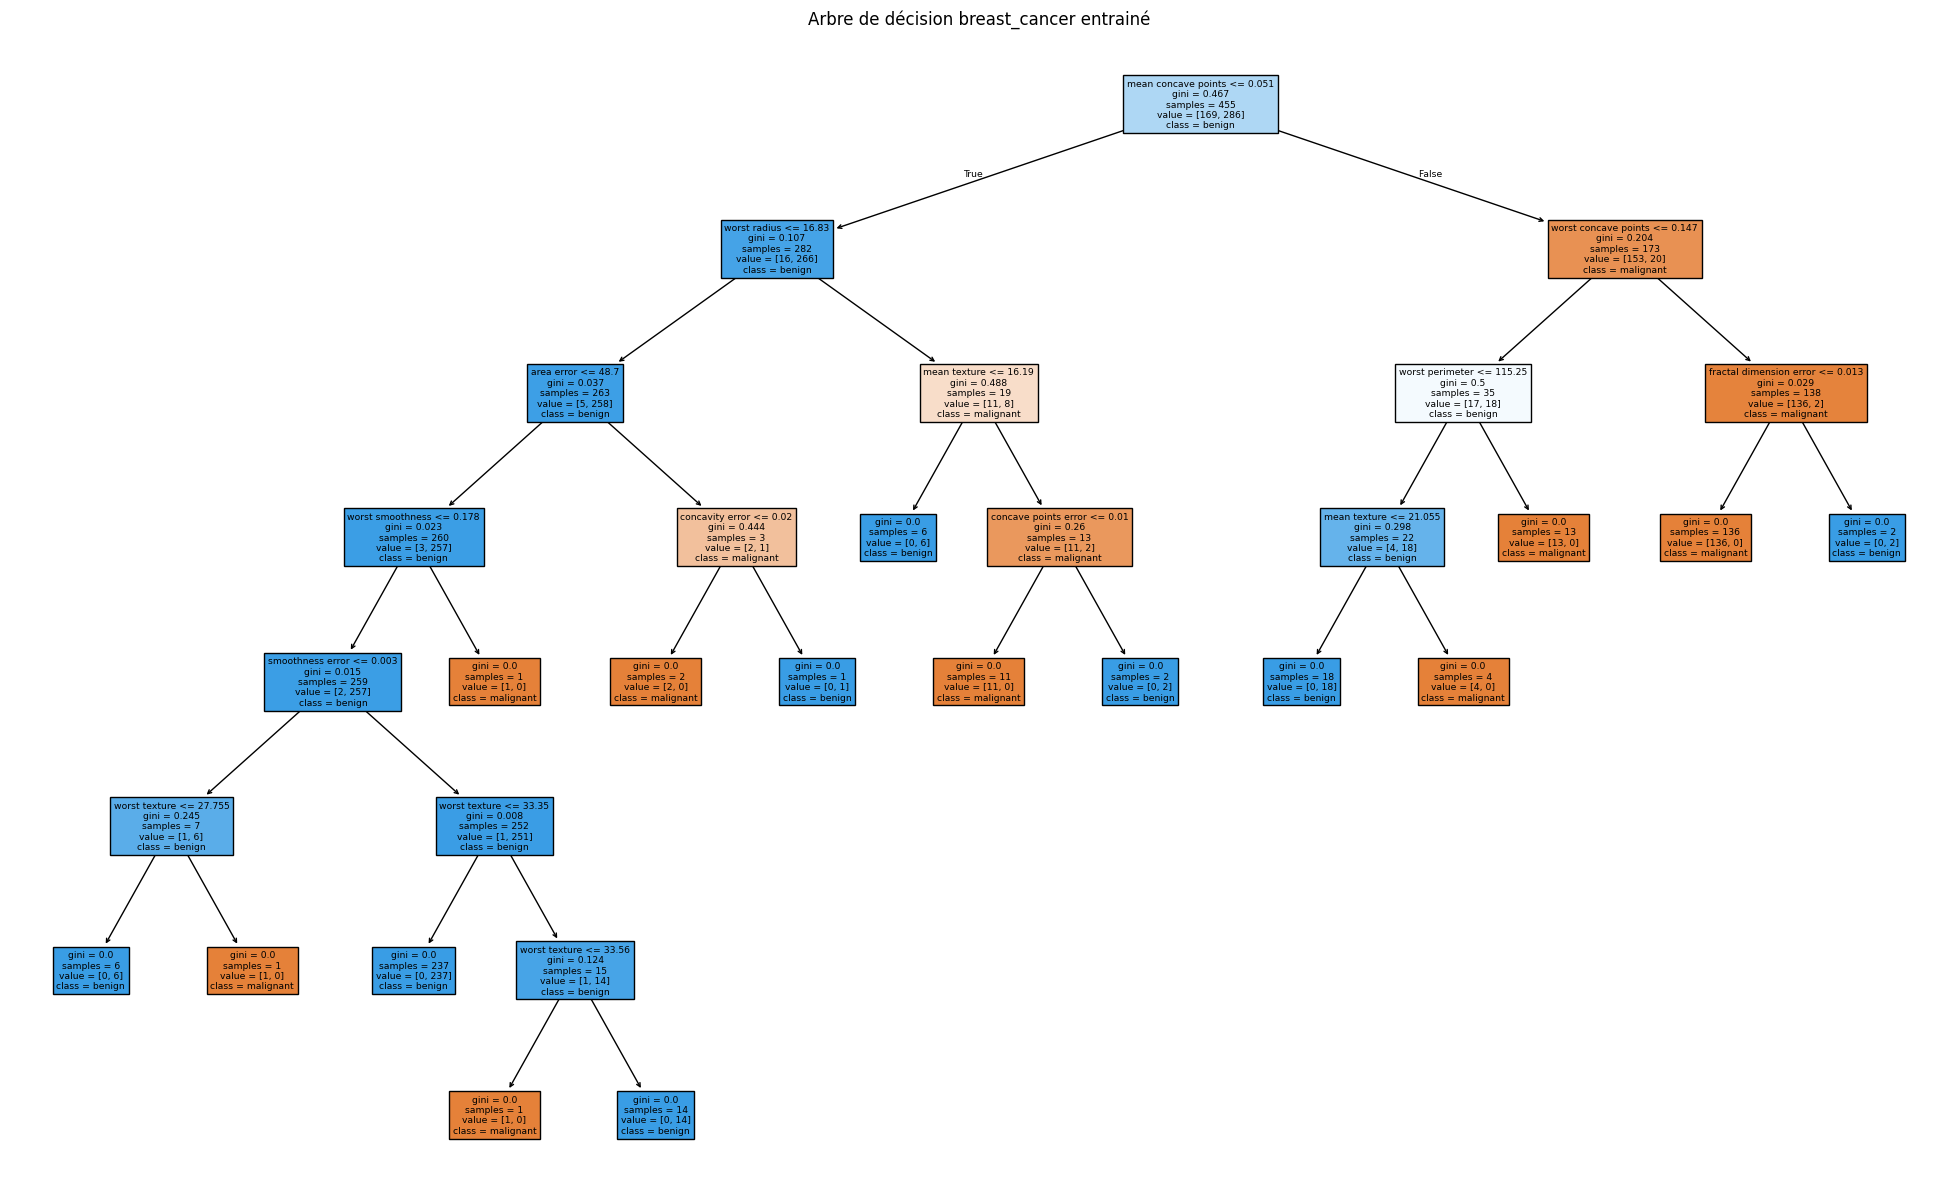

In [11]:
#Visualisation du modèle
plt.figure(figsize=(25,15))
plot_tree(dt_model,feature_names=feature_names,class_names=class_names,filled=True)
plt.title("Arbre de décision breast_cancer entrainé")
plt.show()


In [17]:
#Lutter contre le surapprentissage
dt_model_2=DecisionTreeClassifier(criterion="gini",max_depth=4,min_samples_leaf=5,random_state=42) #j'ai limité la profondeur et controlé le nombre minimum de feuilles
dt_model_2.fit(X_train,Y_train)
Y_pred_2=dt_model_2.predict(X_test)
print("Accuracy de l'arbre de décision sans limite de profondeur ni du nombre de feuilles:",accuracy)
print("Accuracy de l'arbre de décision limité:",accuracy_score(Y_test,Y_pred))





Accuracy de l'arbre de décision sans limite de profondeur ni du nombre de feuilles: 0.9473684210526315
Accuracy de l'arbre de décision limité: 0.9473684210526315


**Conclusion:**
On remarque qu'aprés application des restrictions à mon arbre de décision (comme max_depth=4 et min_samples_leaf=5),le score d'exactitude (accuracy) sur mes données de test reste exactement le même que lorsque l'arbre n'avait aucune limite.
Donc

1.   L'arbre est déjà court par nature
2.   Le surapprentissage était inoffensif sur le Test



In [19]:
#Afin de vérifier la différence entre le premier arbre de décision et le deuxième on peut comparer le score Train vs Test
print("Libre  -> Train:", dt_model.score(X_train, Y_train), "| Test:", dt_model.score(X_test, Y_test))
print("Limité -> Train:", dt_model_2.score(X_train, Y_train), "| Test:", dt_model_2.score(X_test, Y_test))

Libre  -> Train: 1.0 | Test: 0.9473684210526315
Limité -> Train: 0.978021978021978 | Test: 0.9473684210526315


Bien que le score d'entraînement soit plus faible, le **modèle limité (régularisé)** est retenu comme modèle final pour deux raisons majeures :
1. **Capacité de généralisation :** Il est mathématiquement plus robuste et stable, limitant les risques d'effondrement des performances face à de futurs patients.
2. **Interprétabilité (IA Boîte Blanche) :** Avec une profondeur maîtrisée, l'arbre reste lisible, visuellement exploitable et explicable, respectant le principe de simplicité